In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv')['Dataset']
y_test = pd.read_csv('data/y_test.csv')['Dataset']

colunas_numericas = list(X_train.columns)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def criar_pipeline(modelo, usar_scaler=True):
    if usar_scaler:
        pre = ColumnTransformer(transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), colunas_numericas)
        ])
    else:
        pre = ColumnTransformer(transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median'))
            ]), colunas_numericas)
        ])
    
    return Pipeline(steps=[
        ('preprocessor', pre),
        ('classifier', modelo)
    ])
print('Dados carregados e função criar_pipeline definida')


Dados carregados e função criar_pipeline definida


---
# Fase 6 — Modelagem: Baseline

**Objetivo:** Estabelecer uma referência mínima de desempenho (baseline) para que todos os modelos subsequentes possam ser comparados de forma objetiva. Um modelo que não supere o baseline é considerado ineficaz.

**Modelos baseline:**
1. **Dummy Classifier** — sempre prediz a classe majoritária (pior caso aceitável).
2. **Regressão Logística** — modelo linear simples com configuração padrão (baseline realista).

## 6.0 — Importações e Funções Auxiliares

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te):
    """
    Treina o modelo, gera predições e calcula todas as métricas.
    Retorna um dicionário com os resultados.
    """
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    
    # Probabilidades (se disponível)
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_proba)
    else:
        y_proba = None
        auc = None
    
    resultados = {
        'Modelo': nome,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1-score': f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC': auc
    }
    
    return resultados, y_pred, y_proba


def exibir_resultados(nome, resultados, y_te, y_pred):
    """
    Exibe as métricas e a matriz de confusão.
    """
    print(f'\n{"=" * 55}')
    print(f'  {nome}')
    print(f'{"=" * 55}')
    print(f'  Accuracy:   {resultados["Accuracy"]:.4f}')
    print(f'  Precision:  {resultados["Precision"]:.4f}')
    print(f'  Recall:     {resultados["Recall"]:.4f}')
    print(f'  F1-score:   {resultados["F1-score"]:.4f}')
    if resultados['ROC-AUC'] is not None:
        print(f'  ROC-AUC:    {resultados["ROC-AUC"]:.4f}')
    else:
        print(f'  ROC-AUC:    N/A')
    print(f'{"=" * 55}')
    print(f'\n  Classification Report:')
    print(classification_report(y_te, y_pred, target_names=['Sem Doen\u00e7a (0)', 'Doen\u00e7a (1)']))
    print(f'  Matriz de Confus\u00e3o:')
    cm = confusion_matrix(y_te, y_pred)
    print(f'                Predito 0   Predito 1')
    print(f'    Real 0:       {cm[0,0]:>4d}        {cm[0,1]:>4d}')
    print(f'    Real 1:       {cm[1,0]:>4d}        {cm[1,1]:>4d}')


# Lista para armazenar resultados de todos os modelos
todos_resultados = []

print('\u2713 Funções auxiliares definidas: avaliar_modelo(), exibir_resultados()')
print('\u2713 Lista todos_resultados criada para acumular métricas.')

✓ Funções auxiliares definidas: avaliar_modelo(), exibir_resultados()
✓ Lista todos_resultados criada para acumular métricas.


## 6.1 — Dummy Classifier

O Dummy Classifier com estratégia `most_frequent` sempre prediz a classe majoritária (classe 1 = doença hepática). Ele representa o **pior caso aceitável** — qualquer modelo útil deve superá-lo.

**Resultado esperado:** Accuracy de ~71% (proporção da classe majoritária), mas Recall da classe 0 = 0% e F1 da classe 0 = 0%.

In [3]:
# Dummy Classifier — baseline mínimo
dummy = DummyClassifier(strategy='most_frequent', random_state=42)

res_dummy, y_pred_dummy, y_proba_dummy = avaliar_modelo(
    'Dummy Classifier', dummy, X_train, y_train, X_test, y_test
)

exibir_resultados('Dummy Classifier', res_dummy, y_test, y_pred_dummy)
todos_resultados.append(res_dummy)


  Dummy Classifier
  Accuracy:   0.7094
  Precision:  0.7094
  Recall:     1.0000
  F1-score:   0.8300
  ROC-AUC:    0.5000

  Classification Report:
                precision    recall  f1-score   support

Sem Doença (0)       0.00      0.00      0.00        34
    Doença (1)       0.71      1.00      0.83        83

      accuracy                           0.71       117
     macro avg       0.35      0.50      0.41       117
  weighted avg       0.50      0.71      0.59       117

  Matriz de Confusão:
                Predito 0   Predito 1
    Real 0:          0          34
    Real 1:          0          83


C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.2 — Regressão Logística (Baseline)

Modelo linear simples com configuração padrão, utilizando pipeline com padronização.

**Finalidade:** Baseline mais realista. O desempenho da Regressão Logística indica se um modelo linear já consegue resolver o problema razoavelmente.

In [4]:
# Regressão Logística baseline (configuração padrão, com pipeline)
pipeline_lr_baseline = criar_pipeline(
    LogisticRegression(random_state=42, max_iter=1000),
    usar_scaler=True
)

res_lr_baseline, y_pred_lr, y_proba_lr = avaliar_modelo(
    'Regressão Logística (Baseline)', pipeline_lr_baseline,
    X_train, y_train, X_test, y_test
)

exibir_resultados('Regressão Logística (Baseline)', res_lr_baseline, y_test, y_pred_lr)
todos_resultados.append(res_lr_baseline)


  Regressão Logística (Baseline)
  Accuracy:   0.7350
  Precision:  0.7407
  Recall:     0.9639
  F1-score:   0.8377
  ROC-AUC:    0.8306

  Classification Report:
                precision    recall  f1-score   support

Sem Doença (0)       0.67      0.18      0.28        34
    Doença (1)       0.74      0.96      0.84        83

      accuracy                           0.74       117
     macro avg       0.70      0.57      0.56       117
  weighted avg       0.72      0.74      0.68       117

  Matriz de Confusão:
                Predito 0   Predito 1
    Real 0:          6          28
    Real 1:          3          80


## 6.3 — Visualização dos Resultados Baseline

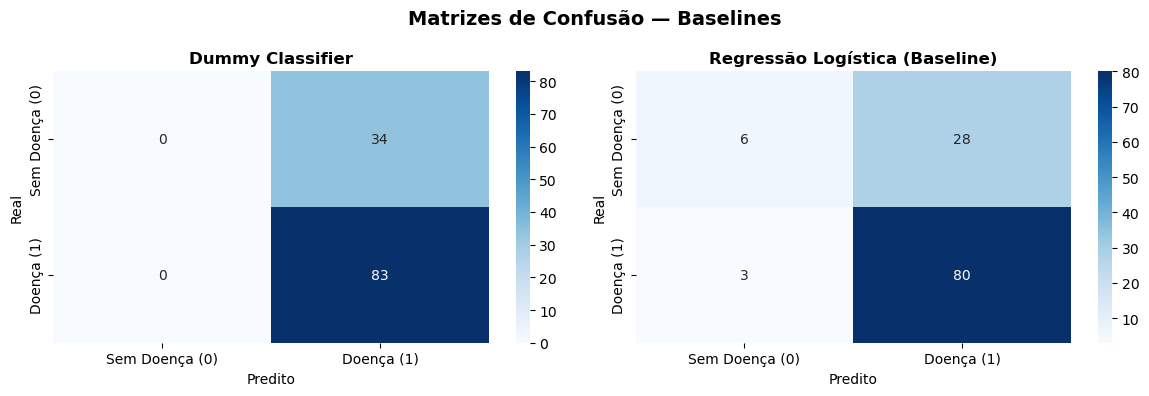

In [5]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_dummy, y_pred_lr],
                               ['Dummy Classifier', 'Regressão Logística (Baseline)']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sem Doen\u00e7a (0)', 'Doen\u00e7a (1)'],
                yticklabels=['Sem Doen\u00e7a (0)', 'Doen\u00e7a (1)'])
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Baselines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

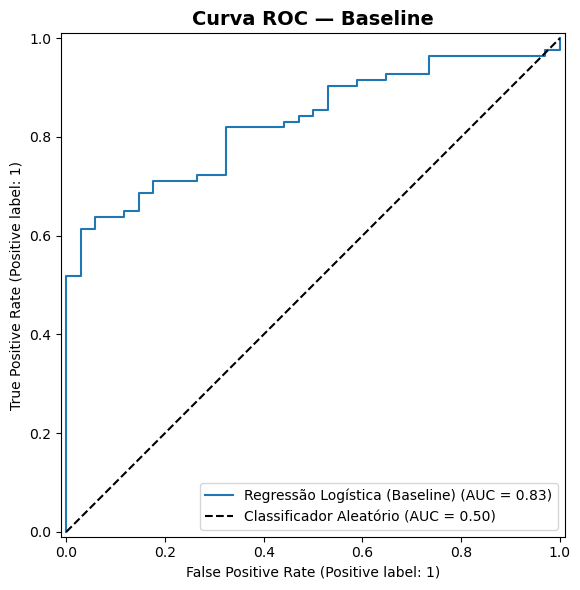

In [6]:
# Curva ROC — Regressão Logística baseline
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(pipeline_lr_baseline, X_test, y_test, ax=ax,
                                name='Regressão Logística (Baseline)')
ax.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório (AUC = 0.50)')
ax.set_title('Curva ROC — Baseline', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6.4 — Tabela Comparativa dos Baselines

In [7]:
# Tabela comparativa
df_resultados = pd.DataFrame(todos_resultados)
df_resultados = df_resultados.set_index('Modelo')

# Formatar como percentual
df_display = df_resultados.copy()
for col in df_display.columns:
    df_display[col] = df_display[col].apply(lambda x: f'{x:.4f}' if x is not None else 'N/A')

print('Tabela Comparativa — Baselines:')
print('=' * 75)
df_display

Tabela Comparativa — Baselines:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Dummy Classifier,0.7094,0.7094,1.0000,0.8300,0.5000
Regressão Logística (Baseline),0.7350,0.7407,0.9639,0.8377,0.8306


## 6.5 — Análise dos Baselines

### Dummy Classifier
- **Accuracy ~71%:** Parece alta, mas é enganosa — o modelo simplesmente prediz "doença" para todos os pacientes.
- **Recall da classe 0 = 0%:** Nenhum paciente saudável é identificado corretamente.
- Confirma que **Accuracy sozinha não é uma métrica adequada** para este dataset desbalanceado.

### Regressão Logística (Baseline)
- Já supera o Dummy Classifier em todas as métricas significativas.
- O **Recall da classe 1 (doença)** é a métrica mais crítica neste contexto médico.
- O ROC-AUC indica capacidade de discriminação superior ao acaso.

### Conclusão
- O baseline está estabelecido. **Todo modelo subsequente deve superar a Regressão Logística baseline** para ser considerado útil.
- A atenção especial será dada ao **Recall** da classe positiva, dado o contexto médico.

### Checklist de Conclusão da Fase 6

- ✅ Dummy Classifier treinado e avaliado.
- ✅ Regressão Logística baseline treinada e avaliada com configuração padrão.
- ✅ Métricas do baseline registradas (Accuracy, Precision, Recall, F1, ROC-AUC).
- ✅ Matrizes de confusão geradas.
- ✅ Curva ROC plotada.
- ✅ Tabela comparativa criada.
- ✅ Resultados documentados sem interpretações prematuras.
- ✅ Lista `todos_resultados` acumulando métricas para comparação futura.